In [ ]:
"""
EGFR peptide-level intensity analysis from PXD017199 Spectronaut MSStats report.

Requires: data/egfr_spectronaut_rows.csv  (produced by fetch_egfr_peptides_ftp.py)

Outputs:
  data/egfr_peptide_intensities.csv        long-format: peptide × cell_line × intensity
  results/egfr_peptide_heatmap.pdf/png     40 peptides × 62 cell lines
  results/egfr_ecto_ic_ratio.pdf/png       ecto/IC ratio per cell line (splicing proxy)
"""
import pathlib
import re

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEP = ";"

# ── Load streamed EGFR rows ────────────────────────────────────────────────────
_NB_DIR = next(
    (
        _p / "figures_paper"
        for _p in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents)
        if (_p / "common.py").is_file()
    ),
    pathlib.Path.cwd(),
)
raw_file = _NB_DIR / "egfr_spectronaut_rows.csv"
if not raw_file.exists():
    raise FileNotFoundError(
        f"{raw_file} not found — run fetch_egfr_peptides_ftp.py first"
    )

print(f"Loading {raw_file} ...")
raw = pd.read_csv(raw_file, sep=SEP, low_memory=False)
print(f"  {len(raw):,} rows, {len(raw.columns)} columns")
print(f"  Columns: {list(raw.columns)}")

# ── Flexible column detection ──────────────────────────────────────────────────
def find_col(df, candidates):
    """Return the first column name that exactly matches or contains any candidate (case-insensitive)."""
    cols_lower = {c.lower(): c for c in df.columns}
    # Exact match first
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    # Substring match
    for cand in candidates:
        for col in df.columns:
            if cand.lower() in col.lower():
                return col
    raise ValueError(f"No column matching {candidates} found in {list(df.columns)}")

# Priority order matters: prefer peptide-level over protein/fragment level
pep_col  = find_col(raw, ["PEP.StrippedSequence", "PeptideSequence", "StrippedPeptide",
                           "PEP.Sequence", "Peptide"])
cond_col = find_col(raw, ["R.Condition", "Condition", "condition", "BioReplicate", "Run"])
# Prefer peptide-level quantity over protein-group or raw fragment peak area
int_col  = find_col(raw, ["PEP.Quantity", "FG.Quantity", "F.NormalizedPeakArea",
                           "F.PeakArea", "PEP.Intensity", "Intensity", "Area"])

print(f"  Peptide col: {pep_col}")
print(f"  Condition col: {cond_col}")
print(f"  Intensity col: {int_col}")

# ── Clean ──────────────────────────────────────────────────────────────────────
raw = raw[[pep_col, cond_col, int_col]].copy()
raw.columns = ["peptide", "condition", "intensity"]

# Strip modifications from peptide sequences
raw["peptide"] = raw["peptide"].apply(
    lambda s: re.sub(r"\[.*?\]|[^A-Za-z]", "", str(s)).upper()
)

# Convert intensity to numeric; 0 → NaN (not detected)
raw["intensity"] = pd.to_numeric(raw["intensity"], errors="coerce")
raw.loc[raw["intensity"] == 0, "intensity"] = np.nan

# Keep only cell-line conditions (drop rows labelled "normal" or empty)
raw = raw[~raw["condition"].str.lower().str.contains("normal", na=True)]
raw = raw.dropna(subset=["condition"])
raw["condition"] = raw["condition"].str.strip()

print(f"  After filtering (no normal, no missing condition): {len(raw):,} rows")
print(f"  Cell lines: {raw['condition'].nunique()}")
print(f"  Unique peptides: {raw['peptide'].nunique()}")

# ── Aggregate: per (peptide, cell line) ───────────────────────────────────────
# PEP.Quantity is constant within a peptide/condition group (one value per sample);
# multiple rows exist per peptide because each row = one fragment ion.
# Use first non-null value;
agg = (raw.dropna(subset=["intensity"])
        .groupby(["peptide", "condition"])["intensity"]
        .first()
        .reset_index()
        .rename(columns={"intensity": "median_intensity"}))

# ── Load peptide isoform classes ───────────────────────────────────────────────
pep_map = pd.read_csv(_NB_DIR / "egfr_peptides_mapped.csv").dropna(subset=["start"])
pep_map["start"] = pep_map["start"].astype(int)
pep_map["end"]   = pep_map["end"].astype(int)

# Load isoform presence matrix produced by egfr_splicing_analysis.py
iso_matrix_file = _NB_DIR / "egfr_isoform_presence_matrix.csv"
iso_mat = pd.read_csv(iso_matrix_file, index_col=0)
# Classify: constitutive / iso2_absent / canonical_only
def iso_class(pep_seq):
    if pep_seq not in iso_mat.index:
        return "unknown"
    row = iso_mat.loc[pep_seq]
    in2 = row.get("P00533-2", False)
    in3 = row.get("P00533-3", False)
    in4 = row.get("P00533-4", False)
    if in2 and in3 and in4:
        return "constitutive"
    if not in2 and in3 and in4:
        return "iso2_absent"
    if not in2 and not in3 and not in4:
        return "canonical_only"
    return "other"
pep_map["isoform_class"] = pep_map["peptide"].apply(iso_class)

# Merge
merged = agg.merge(pep_map[["peptide", "start", "end", "domain", "isoform_class"]],
                   on="peptide", how="inner")

print(f"\nAfter merging with peptide map: {len(merged):,} rows")
print(f"  Mapped peptides: {merged['peptide'].nunique()} / {len(pep_map)}")
print(f"  Cell lines with data: {merged['condition'].nunique()}")

# Save long-format
long_out = _NB_DIR / "egfr_peptide_intensities.csv"
merged.to_csv(long_out, index=False)
print(f"  Saved long-format to {long_out}")

# ── Build wide matrix: peptides × cell lines ───────────────────────────────────
wide = merged.pivot_table(index="peptide", columns="condition",
                          values="median_intensity", aggfunc="median")

# Sort peptides by position
pep_order = pep_map.sort_values("start")["peptide"].tolist()
pep_order = [p for p in pep_order if p in wide.index]
wide = wide.loc[pep_order]

# Sort cell lines by EGFR protein-level log2FC
log2fc_file = _NB_DIR / "egfr_log2fc.csv"
log2fc = pd.read_csv(log2fc_file).dropna(subset=["log2FC"])
log2fc["log2FC_num"] = pd.to_numeric(log2fc["log2FC"].replace([np.inf, -np.inf], np.nan),
                                        errors="coerce")
cell_order = (log2fc.sort_values("log2FC_num", na_position="last")["cell_line"]
                .tolist())
cell_order = [c for c in cell_order if c in wide.columns]
missing_cols = [c for c in wide.columns if c not in cell_order]
cell_order = cell_order + missing_cols

wide = wide[cell_order]

pep_class = pep_map.set_index("peptide")["isoform_class"]
constitutive_peps = [p for p in wide.index if pep_class.get(p) == "constitutive"]
canonical_peps    = [p for p in wide.index if pep_class.get(p) == "canonical_only"]

Loading egfr_spectronaut_rows.csv ...
  65,412 rows, 29 columns
  Columns: ['R.Condition', 'R.FileName', 'R.Replicate', 'PG.ProteinAccessions', 'PG.ProteinGroups', 'PG.Quantity', 'PEP.GroupingKey', 'PEP.StrippedSequence', 'PEP.Quantity', 'EG.iRTPredicted', 'EG.Library', 'EG.ModifiedSequence', 'EG.PrecursorId', 'EG.Qvalue', 'FG.Charge', 'FG.Id', 'FG.PrecMz', 'FG.Quantity', 'F.Charge', 'F.FrgIon', 'F.FrgLossType', 'F.FrgMz', 'F.FrgNum', 'F.FrgType', 'F.ExcludedFromQuantification', 'F.NormalizedPeakArea', 'F.NormalizedPeakHeight', 'F.PeakArea', 'F.PeakHeight\r']
  Peptide col: PEP.StrippedSequence
  Condition col: R.Condition
  Intensity col: PEP.Quantity
  After filtering (no normal, no missing condition): 65,412 rows
  Cell lines: 67
  Unique peptides: 40

After merging with peptide map: 1,140 rows
  Mapped peptides: 40 / 40
  Cell lines with data: 63
  Saved long-format to egfr_peptide_intensities.csv


Saved egfr_peptide_heatmap.pdf
Saved egfr_peptide_heatmap.png


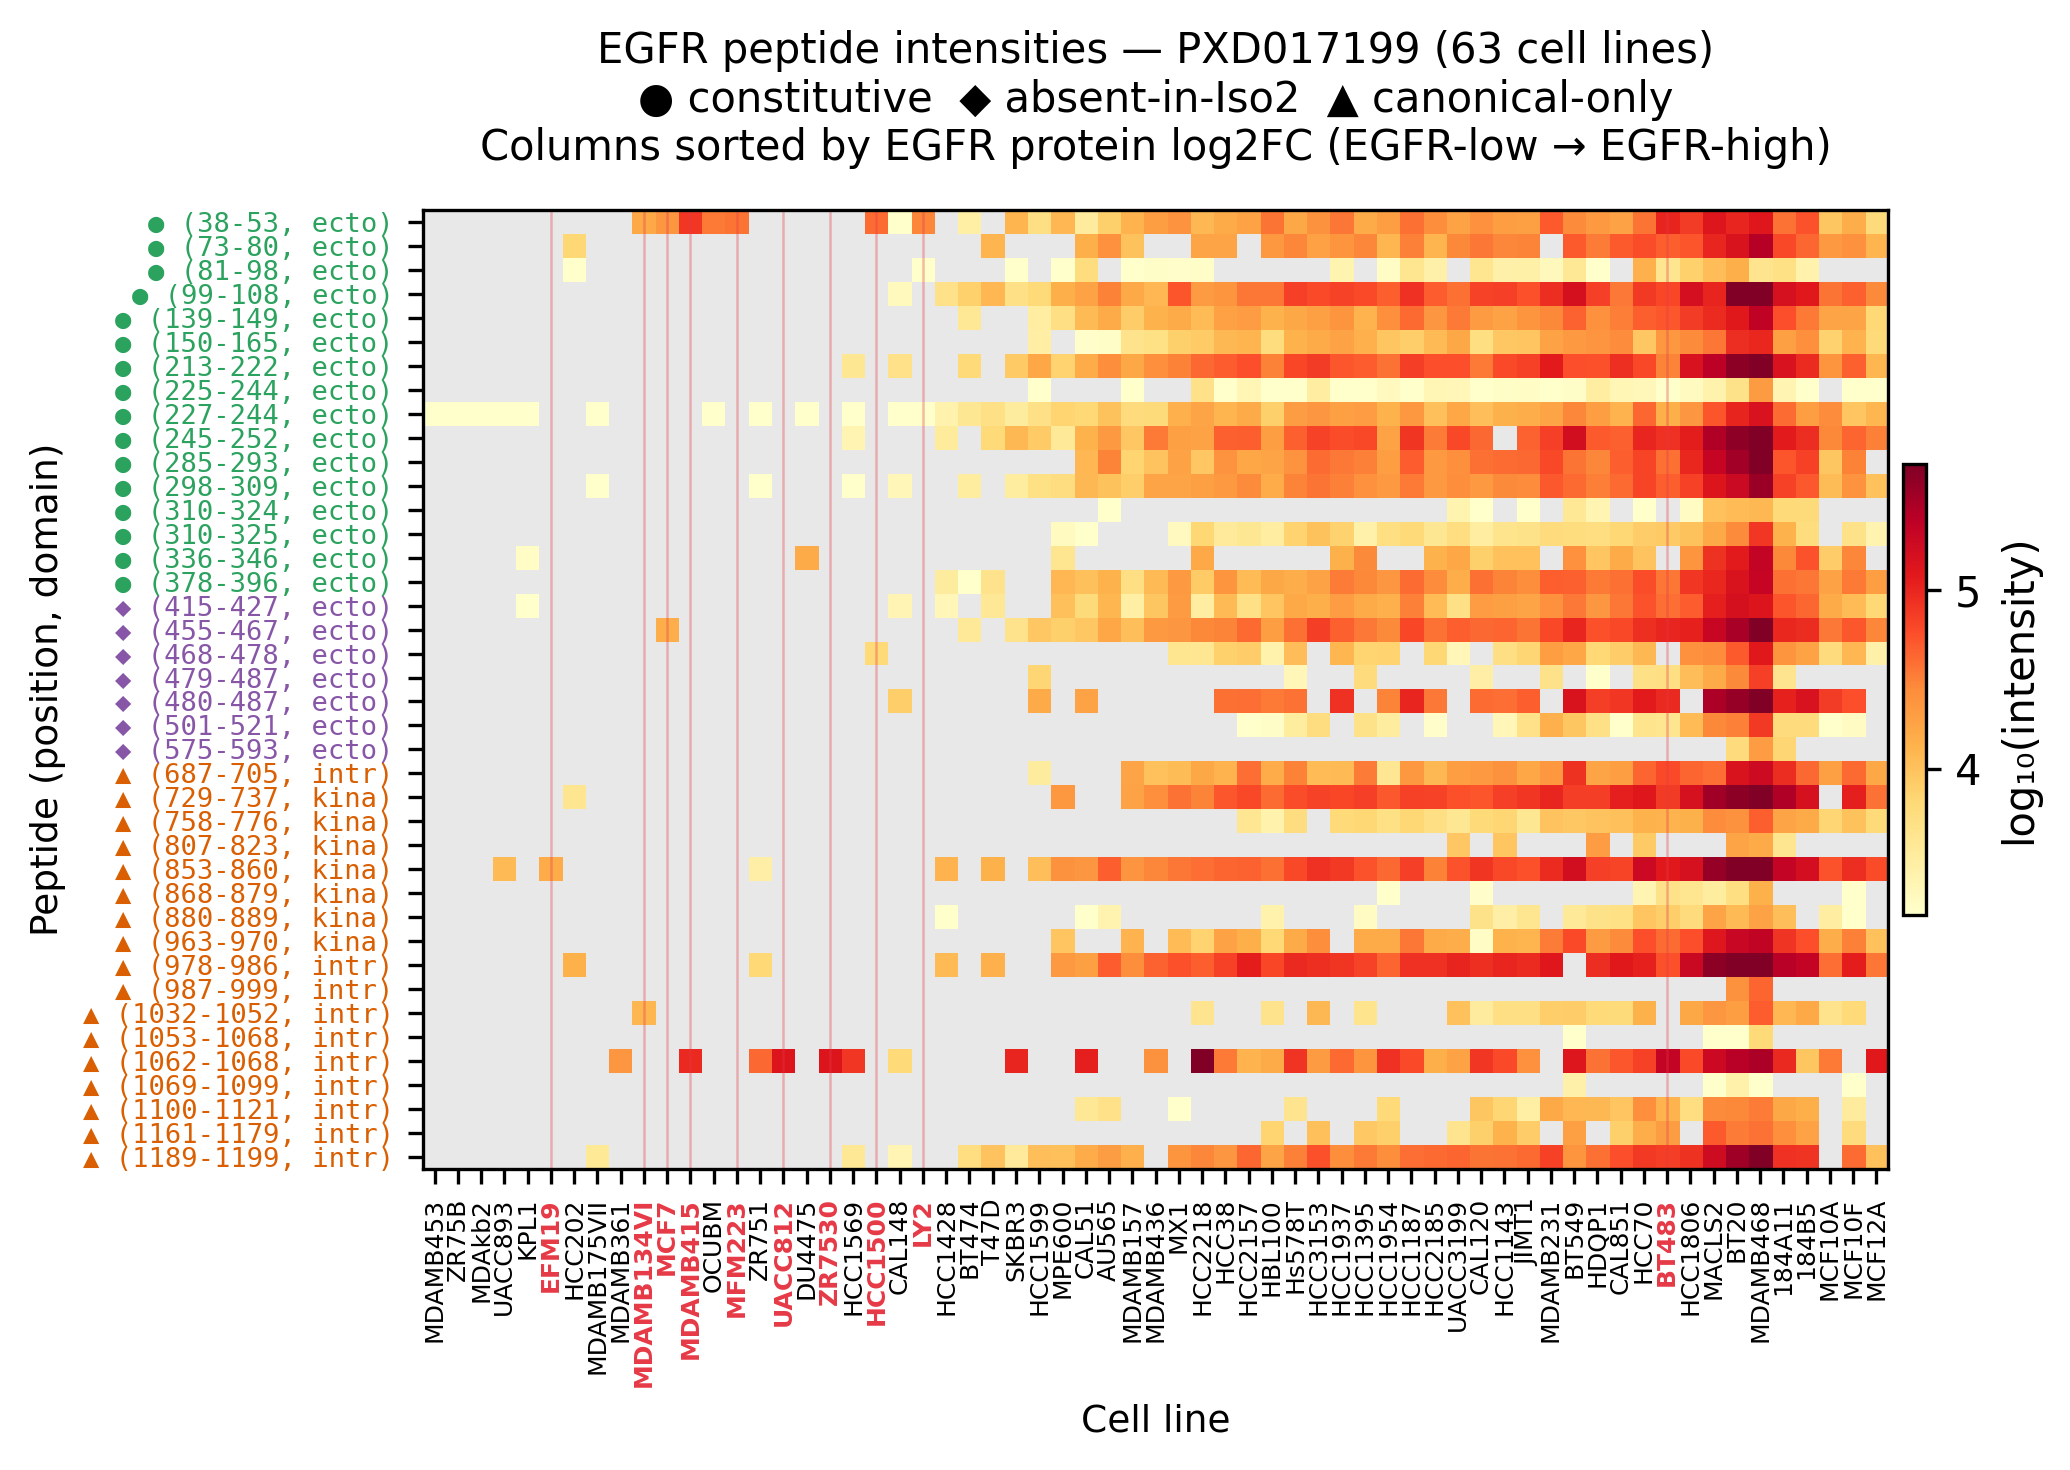

In [ ]:
# ── Figure 1: Peptide × Cell line heatmap ─────────────────────────────────────
n_peps  = len(wide)
n_cells = len(wide.columns)

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)


# log10 intensity matrix, NaN = not detected
mat = np.log10(wide.values + 1)  # +1 to avoid log(0)
mat[np.isnan(np.log10(wide.values))] = np.nan

vmin = np.nanpercentile(mat[mat > 0], 5)  if np.any(mat > 0) else 0
vmax = np.nanpercentile(mat, 99)

cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color="#e8e8e8")

im = ax.imshow(mat, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax,
               interpolation="nearest")

# Axis labels
ax.set_xticks(range(n_cells))
ax.set_xticklabels(wide.columns.tolist(), rotation=90, fontsize=6)

# Highlight selected cell lines
HIGHLIGHT_CELLS = {
    "BT483", "EFM19", "HCC1500", "LY2", "MCF7",
    "MDAMB134VI", "MDAMB415", "MFM223", "UACC812", "ZR7530",
}
for i, lbl in enumerate(ax.get_xticklabels()):
    if lbl.get_text() in HIGHLIGHT_CELLS:
        lbl.set_color("#e63946")
        lbl.set_fontweight("bold")
        ax.axvline(x=i, color="#e63946", linewidth=0.6, alpha=0.35, zorder=0)

ax.set_yticks(range(n_peps))

# Row labels with domain and isoform class
CLASS_SYMBOLS = {"constitutive": "●", "iso2_absent": "◆", "canonical_only": "▲", "unknown": "?"}
CLASS_COLORS  = {"constitutive": "#2ca25f", "iso2_absent": "#8856a7",
                 "canonical_only": "#d95f02", "unknown": "#aaa"}
row_labels = []
for pep in pep_order:
    if pep not in pep_map["peptide"].values:
        row_labels.append(pep)
        continue
    r = pep_map[pep_map["peptide"] == pep].iloc[0]
    sym = CLASS_SYMBOLS.get(r["isoform_class"], "?")
    row_labels.append(f"{sym} ({r['start']}-{r['end']}, {r['domain'][:4]})")

ax.set_yticklabels(row_labels, fontsize=6.5, fontfamily="monospace")

# Colour bar and title
plt.colorbar(im, ax=ax, orientation="vertical", fraction=0.015, pad=0.01,
             label="log₁₀(intensity)")
ax.set_title(f"EGFR peptide intensities — PXD017199 ({n_cells} cell lines)\n"
             f"● constitutive  ◆ absent-in-Iso2  ▲ canonical-only\n"
             f"Columns sorted by EGFR protein log2FC (EGFR-low → EGFR-high)",
             fontsize=10, pad=12)
ax.set_xlabel("Cell line", fontsize=9)
ax.set_ylabel("Peptide (position, domain)", fontsize=9)

# Coloured row indicator strip (left margin using text colour)
for i, pep in enumerate(pep_order):
    if pep in pep_class.index:
        cls = pep_class[pep]
        ax.get_yticklabels()[i].set_color(CLASS_COLORS.get(cls, "black"))

plt.tight_layout()
for ext in ("pdf", "png"):
    out = f"egfr_peptide_heatmap.{ext}"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved {out}")
plt.show()